# Grid Initialisation — Analysis

This notebook compares three initialisation strategies:

- `random` -- fully random vertices and colors (baseline)
- `image`  -- random vertices, colors sampled from target at centroid
- `grid`   -- vertices anchored to canvas grid, colors from target

All other GA settings are identical across runs to isolate the effect of initialisation.

In [17]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from IPython.display import display
from PIL import Image
import copy

import logging
logging.basicConfig(level=logging.WARNING)  # suppress per-generation logs for clean output

from fitness import build_fitness
from utils import load_target_pil, side_by_side, render, save_render
from ga import GeneticAlgorithm, GAConfig, EarlyStopping

from ga_operators.selection import TournamentSelection, RankSelection, RouletteSelection
from ga_operators.crossover import SinglePointCrossover, UniformCrossover, KPointCrossover
from ga_operators.mutation import GaussianMutation, ResetMutation, SwapMutation, CompositeMutation



TARGET_PATH = '../data/Girl_Pearl_Earing.png'
OUTPUT_DIR  = '../outputs/init_comparison2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('imports ok')

imports ok


## 1. Load target image

size (W x H) : (300, 400)
array shape  : (400, 300, 3), dtype: uint8


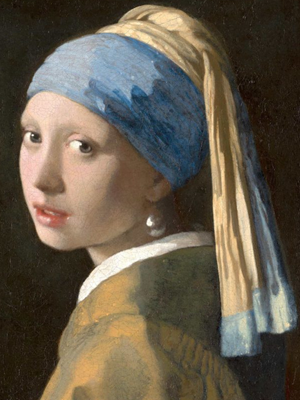

In [18]:
target_pil   = load_target_pil(TARGET_PATH)
target_array = np.array(target_pil)

print(f'size (W x H) : {target_pil.size}')
print(f'array shape  : {target_array.shape}, dtype: {target_array.dtype}')
display(target_pil)

## 2. Visualise grid initialisation

Before running the full GA, render one grid-initialised individual to see
what the starting point looks like visually.

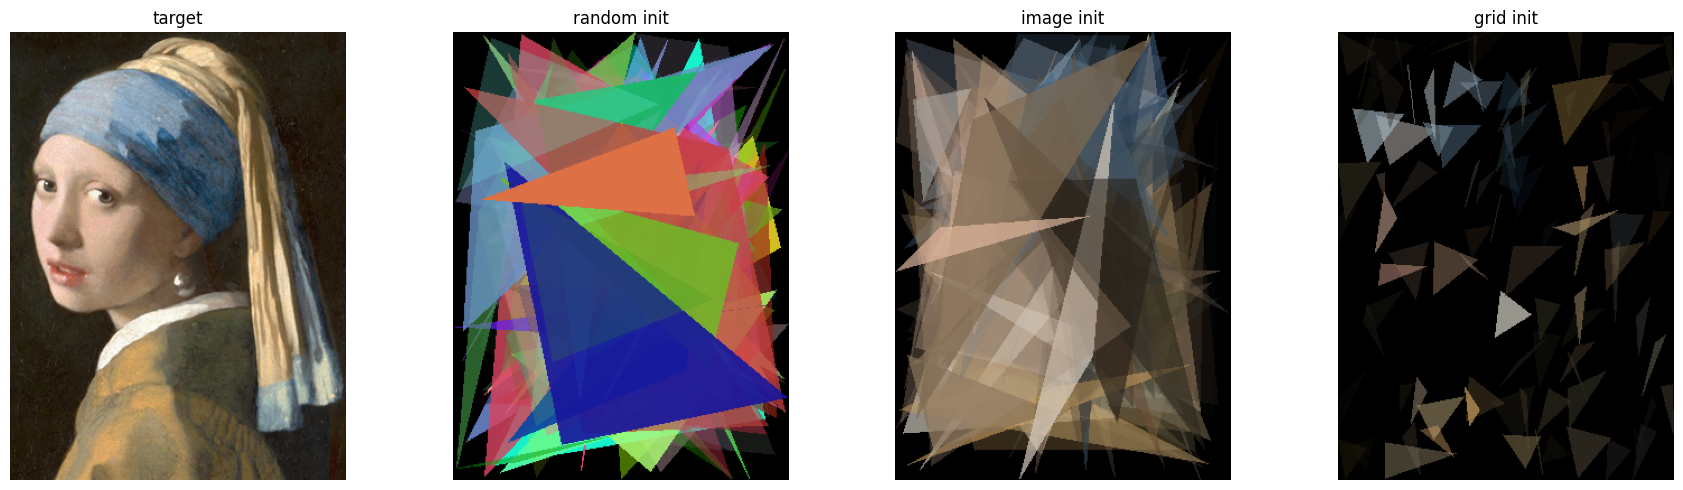

random init fitness : 80.4580
image  init fitness : 62.8662
grid   init fitness : 98.2900


In [19]:
from fitness import build_fitness
from individual import Individual

rng_preview = np.random.default_rng(0)
fitness_fn  = build_fitness('rmse', target_pil)

ind_random = Individual.random(fitness_fn, rng_preview)
ind_image  = Individual.from_image(fitness_fn, rng_preview, target_array)
ind_grid   = Individual.from_grid(fitness_fn, rng_preview, target_array)

arr_random = render(ind_random.triangles)
arr_image  = render(ind_image.triangles)
arr_grid   = render(ind_grid.triangles)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, arr, title in zip(
    axes,
    [target_array, arr_random, arr_image, arr_grid],
    ['target', 'random init', 'image init', 'grid init'],
):
    ax.imshow(arr)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/init_visual_comparison.png', dpi=150)
plt.show()

# Show generation-0 fitness for each strategy
print(f'random init fitness : {ind_random.fitness:.4f}')
print(f'image  init fitness : {ind_image.fitness:.4f}')
print(f'grid   init fitness : {ind_grid.fitness:.4f}')

## 3. Shared GA config

All three runs use identical settings. Only `init_strategy` differs.

In [20]:
N_GENERATIONS  = 2000   # keep short for comparison — increase for final runs
POPULATION     = 30
SEED           = 42

def make_ga(fitness_fn):
    """Build a GA instance with fixed config. Called once per strategy."""
    config = GAConfig(
        population_size     = POPULATION,
        n_generations       = N_GENERATIONS,
        crossover_rate      = 0.8,
        n_elites            = 1,
        n_workers           = 1,
        early_stopping      = EarlyStopping(patience=0),   # disabled -- run full N gens
        checkpoint_interval = 0,                           # disabled
        seed                = SEED,
    )
    mutation = CompositeMutation([
        GaussianMutation(mutation_rate=0.05, vertex_sigma=15.0, color_sigma=15.0),
        ResetMutation(mutation_rate=0.01),
        SwapMutation(mutation_rate=0.2, n_swaps=1),
    ])
    return GeneticAlgorithm(
        fitness_fn = fitness_fn,
        selection  = TournamentSelection(tournament_size=5),
        crossover  = SinglePointCrossover(),
        mutation   = mutation,
        config     = config,
    )

print(f'config: {POPULATION} individuals x {N_GENERATIONS} generations, seed={SEED}')

config: 30 individuals x 2000 generations, seed=42


## 4. Run all three strategies

In [21]:
fitness_fn = build_fitness('rmse', target_pil)
strategies = ['random', 'image', 'grid']
results    = {}   # strategy -> {'log': pd.DataFrame, 'best': Individual}

for strategy in strategies:
    print(f'running strategy: {strategy} ...', end=' ', flush=True)
    ga   = make_ga(fitness_fn)
    best = ga.run(target=target_array, init_strategy=strategy)
    results[strategy] = {
        'log':  pd.DataFrame(ga.generation_log),
        'best': best,
    }
    print(f'done. best fitness = {best.fitness:.4f}')

print('all runs complete')

running strategy: random ... done. best fitness = 32.3139
running strategy: image ... done. best fitness = 31.1784
running strategy: grid ... done. best fitness = 32.4815
all runs complete


## 5. Convergence comparison

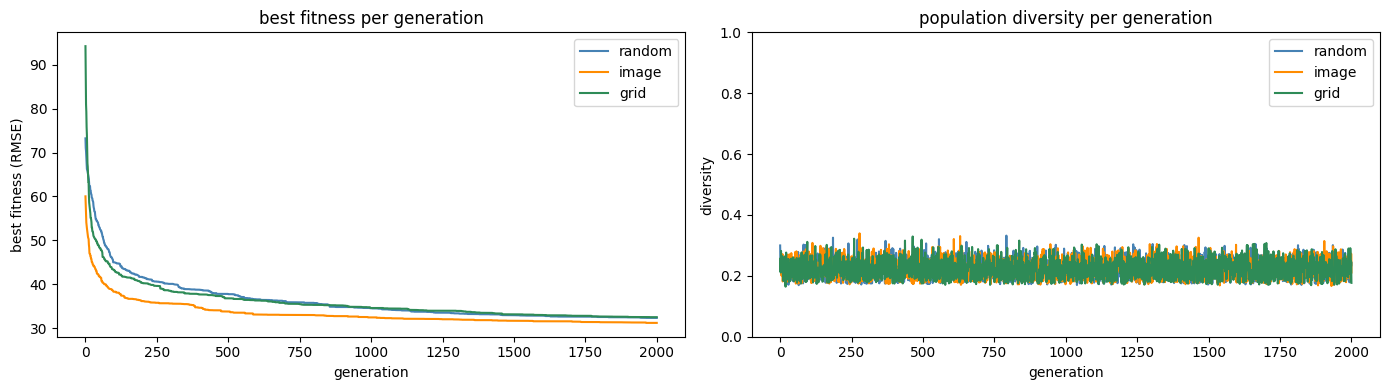

In [22]:
colors = {'random': 'steelblue', 'image': 'darkorange', 'grid': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: best fitness per generation
ax = axes[0]
for strategy, res in results.items():
    log = res['log']
    ax.plot(log['generation'], log['best'],
            label=strategy, color=colors[strategy], linewidth=1.5)
ax.set_xlabel('generation')
ax.set_ylabel('best fitness (RMSE)')
ax.set_title('best fitness per generation')
ax.legend()

# right: population diversity per generation
ax2 = axes[1]
for strategy, res in results.items():
    log = res['log']
    ax2.plot(log['generation'], log['diversity'],
             label=strategy, color=colors[strategy], linewidth=1.5)
ax2.set_xlabel('generation')
ax2.set_ylabel('diversity')
ax2.set_title('population diversity per generation')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/convergence_comparison.png', dpi=150)
plt.show()

## 6. Summary table

In [23]:
rows = []
for strategy, res in results.items():
    log = res['log']
    rows.append({
        'strategy':         strategy,
        'gen0_fitness':     round(log['best'].iloc[0],  4),
        'final_fitness':    round(log['best'].iloc[-1], 4),
        'improvement':      round(log['best'].iloc[0] - log['best'].iloc[-1], 4),
        'gen0_diversity':   round(log['diversity'].iloc[0],  4),
        'final_diversity':  round(log['diversity'].iloc[-1], 4),
        'elapsed_s':        round(log['elapsed_s'].iloc[-1], 1),
    })

summary = pd.DataFrame(rows).set_index('strategy')
summary.to_csv(f'{OUTPUT_DIR}/summary.csv')
display(summary)

,gen0_fitness,final_fitness,improvement,gen0_diversity,final_diversity,elapsed_s
strategy,,,,,,
random,73.2346,32.3139,40.9207,0.2998,0.2416,504.3
image,60.0200,31.1784,28.8416,0.2166,0.2111,495.4
grid,94.2496,32.4815,61.7681,0.2180,0.1769,509.2


## 7. Visual comparison of best individuals

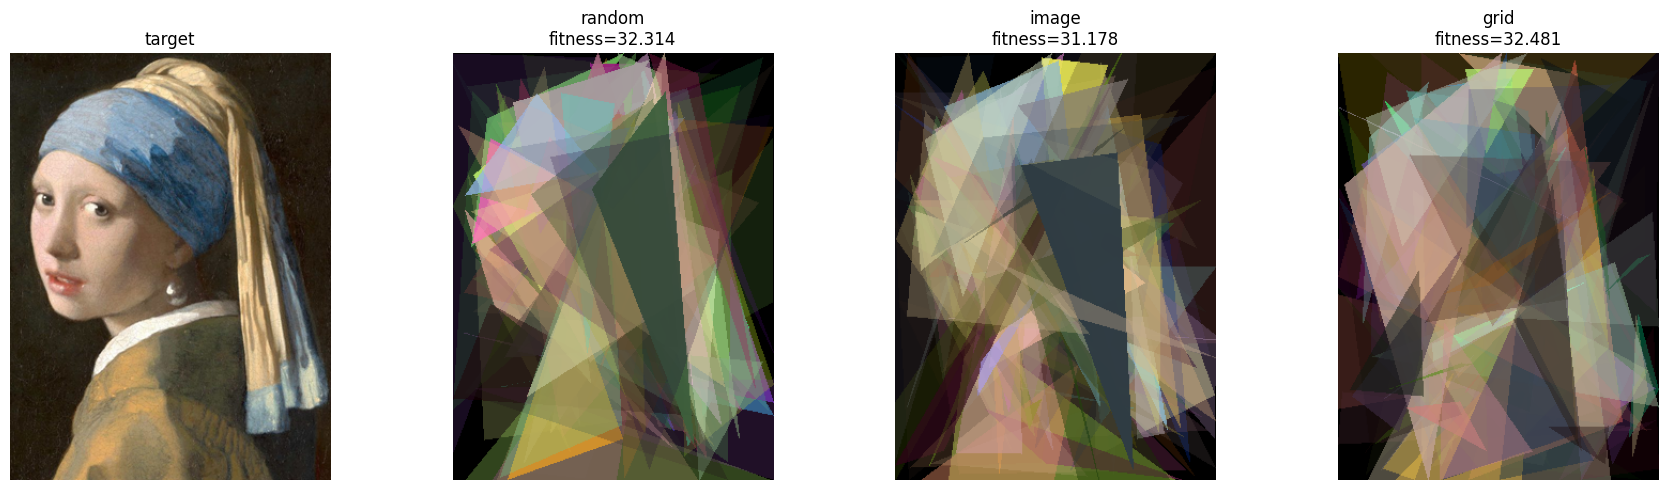

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(target_array)
axes[0].set_title('target')
axes[0].axis('off')

for ax, strategy in zip(axes[1:], strategies):
    best = results[strategy]['best']
    arr  = render(best.triangles)
    save_render(arr, f'{OUTPUT_DIR}/best_{strategy}.png')
    ax.imshow(arr)
    ax.set_title(f'{strategy}\nfitness={best.fitness:.3f}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/best_visual_comparison.png', dpi=150)
plt.show()

## 8. Early-generation zoom

Plot only the first 20 generations to clearly show the initialisation advantage.

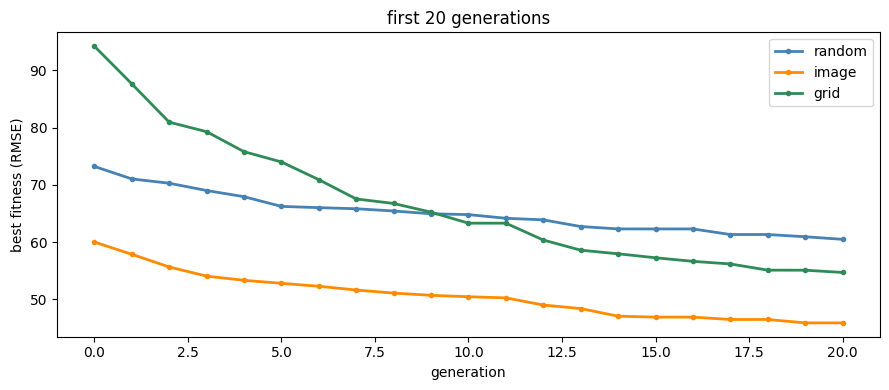

In [25]:
ZOOM_GENS = 20

fig, ax = plt.subplots(figsize=(9, 4))
for strategy, res in results.items():
    log = res['log']
    early = log[log['generation'] <= ZOOM_GENS]
    ax.plot(early['generation'], early['best'],
            label=strategy, color=colors[strategy], linewidth=2.0, marker='o', markersize=3)

ax.set_xlabel('generation')
ax.set_ylabel('best fitness (RMSE)')
ax.set_title(f'first {ZOOM_GENS} generations')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/early_convergence.png', dpi=150)
plt.show()